# Melhorando EEGNet para Motor Imagery BCI

**Baseline**: EEGNet 4-class, Subject 1, acc=66.7%, kappa=0.556

**Objetivo**: Maximizar acurácia no test set para integração com jogo online (left/right)

**Roteiro de melhorias**:
1. Redução para 2 classes (left hand vs right hand)
2. Ajuste de banda (8-30 Hz, foco em mu/beta)
3. Data augmentation: Gaussian noise
4. Data augmentation: sliding window temporal
5. Pipeline completo + comparação
6. Salvar melhor modelo para uso online

## 0. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import mne
from mne.io import read_raw_gdf
from scipy.io import loadmat

import tensorflow as tf
# Forçar CPU-only (DirectML não suporta channels_first backprop)
tf.config.set_visible_devices(tf.config.list_physical_devices('CPU'))

from tensorflow.keras import Model, Input
from tensorflow.keras.layers import (
    Conv2D, DepthwiseConv2D, SeparableConv2D,
    BatchNormalization, Activation, AveragePooling2D,
    Dropout, Flatten, Dense
)
from tensorflow.keras.constraints import max_norm
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import confusion_matrix, classification_report, cohen_kappa_score

mne.set_log_level('WARNING')
print(f'MNE {mne.__version__} | TF {tf.__version__}')
print(f'Devices: {[d.name for d in tf.config.get_visible_devices()]}')

MNE 1.12.1 | TF 2.21.0
Devices: ['/physical_device:CPU:0']


In [2]:
# --- Paths & Constants ---
NOTEBOOK_DIR = Path(r'C:\Users\pedro\Workspaces\EEG_learning')
DATA_DIR     = NOTEBOOK_DIR / 'data' / 'bcic_iv_2a'
LABELS_DIR   = NOTEBOOK_DIR / 'data' / 'true_labels'
MODELS_DIR   = NOTEBOOK_DIR / 'models'
MODELS_DIR.mkdir(exist_ok=True)

SFREQ      = 250
N_CHANNELS = 22
SUBJECT_ID = 1

# Tracker de resultados: {nome_experimento: {acc, kappa, n_train}}
results = {}

In [3]:
# --- Infraestrutura (fornecida) ---

CLASS_LABELS = ['Left Hand', 'Right Hand', 'Feet', 'Tongue']

def build_eegnet(
    n_channels: int  = 22,
    n_times: int     = 1001,
    n_classes: int   = 2,
    sfreq: int       = 250,
    F1: int          = 8,
    D: int           = 2,
    F2: int          = 16,
    dropout_rate: float = 0.5,
) -> Model:
    kern_len = sfreq // 2
    inputs = Input(shape=(1, n_channels, n_times), name='eeg_input')

    x = Conv2D(F1, (1, kern_len), padding='same', use_bias=False,
               data_format='channels_first', name='temporal_conv')(inputs)
    x = BatchNormalization(axis=1)(x)

    x = DepthwiseConv2D((n_channels, 1), depth_multiplier=D,
                        depthwise_constraint=max_norm(1.0), use_bias=False,
                        data_format='channels_first', name='spatial_conv')(x)
    x = BatchNormalization(axis=1)(x)
    x = Activation('elu')(x)
    x = AveragePooling2D((1, 4), data_format='channels_first')(x)
    x = Dropout(dropout_rate)(x)

    x = SeparableConv2D(F2, (1, 16), padding='same', use_bias=False,
                        data_format='channels_first', name='separable_conv')(x)
    x = BatchNormalization(axis=1)(x)
    x = Activation('elu')(x)
    x = AveragePooling2D((1, 8), data_format='channels_first')(x)
    x = Dropout(dropout_rate)(x)

    x = Flatten()(x)
    outputs = Dense(n_classes, activation='softmax',
                    kernel_constraint=max_norm(0.25), name='classifier')(x)

    return Model(inputs, outputs, name='EEGNet')


def normalize_per_epoch(X: np.ndarray) -> np.ndarray:
    mu  = X.mean(axis=(1, 2), keepdims=True)
    std = X.std(axis=(1, 2), keepdims=True) + 1e-8
    return (X - mu) / std


def reshape_for_eegnet(X: np.ndarray) -> np.ndarray:
    return X[:, np.newaxis, :, :]  # (n, 1, C, T)


def prepare(X: np.ndarray) -> np.ndarray:
    """Normalize + reshape em um passo."""
    return reshape_for_eegnet(normalize_per_epoch(X))


def train_and_evaluate(X_train, y_train, X_test, y_test,
                       n_classes=2, experiment_name='exp',
                       epochs=300, batch_size=32, patience=20):
    """Treina EEGNet e retorna métricas. Salva no dict results."""
    n_times = X_train.shape[-1]
    model = build_eegnet(N_CHANNELS, n_times, n_classes, SFREQ)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    history = model.fit(
        X_train, y_train,
        epochs=epochs, batch_size=batch_size,
        validation_split=0.2,
        callbacks=[
            EarlyStopping(monitor='val_loss', patience=patience,
                          restore_best_weights=True),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                              patience=10, min_lr=1e-5),
        ],
        verbose=1,
    )

    y_pred = np.argmax(model.predict(X_test), axis=1)
    acc   = (y_pred == y_test).mean()
    kappa = cohen_kappa_score(y_test, y_pred)

    results[experiment_name] = {
        'accuracy': acc, 'kappa': kappa,
        'n_train': len(X_train), 'n_test': len(X_test),
    }
    print(f'\n=== {experiment_name} ===')
    print(f'Train size: {len(X_train)} | Test size: {len(X_test)}')
    print(f'Accuracy: {acc:.4f} | Kappa: {kappa:.4f}')
    print(classification_report(y_test, y_pred,
          target_names=CLASS_LABELS[:n_classes]))

    return model, history

print('Infraestrutura carregada.')

Infraestrutura carregada.


---
## Exercício 1 — Baseline 2 Classes (Left Hand vs Right Hand)

### Pense Primeiro

No notebook anterior, tínhamos 4 classes com acurácia de 66.7%. Se reduzirmos para 2 classes:
- O que acontece com o *chance level*?
- Olhando a matriz de confusão anterior, Left Hand tinha 67% recall e Right Hand 94%. De onde vinham os erros dessas classes? Eram confusões *entre si* ou com Feet/Tongue?
- Eliminar Feet e Tongue remove confusão ou remove informação útil?

### Contexto

A imaginação motora de mão esquerda vs mão direita produz padrões de **ERD/ERS contralateral** — quando você imagina mover a mão direita, o ritmo mu (8-13 Hz) *dessincroniza* sobre o córtex motor esquerdo (eletrodo C3) e pode *sincronizar* no lado ipsilateral (C4). O padrão é espelhado para mão esquerda.

Isso significa que left vs right é o par de classes com a **separabilidade neurofisiológica mais clara** — os padrões são literalmente em hemisférios opostos do cérebro. Feet e tongue usam representações corticais na linha mediana (Cz), que são mais difíceis de separar e podem causar confusão.

### Exercício

Implemente `load_subject_2class` — uma versão modificada de `load_subject` que retorna apenas trials de left hand (label 0) e right hand (label 1).

In [4]:
def load_subject_2class(subject_id: int, split: str = 'T',
                        l_freq: float = 4.0, h_freq: float = 40.0):
    """
    Load one subject, keeping only left hand (0) and right hand (1).

    Returns:
        X: (n_epochs, 22, n_times) float32
        y: (n_epochs,) int32, values in {0, 1}
    """
    fname = DATA_DIR / f'A0{subject_id}{split}.gdf'
    raw = read_raw_gdf(str(fname), preload=True, verbose=False)

    raw.pick_types(eeg=True)
    raw.pick(raw.ch_names[:N_CHANNELS])
    raw.filter(l_freq=l_freq, h_freq=h_freq, method='iir', verbose=False)

    if split == 'T':
        # Training: só left hand (769) e right hand (770)
        event_id = {'left_hand': 769, 'right_hand': 770}
        ann_to_code = {str(v): v for v in event_id.values()}
        events, _ = mne.events_from_annotations(raw, event_id=ann_to_code, verbose=False)
        events = events[np.isin(events[:, 2], list(event_id.values()))]

        epochs = mne.Epochs(raw, events, event_id=event_id,
                            tmin=0.0, tmax=4.0, baseline=None,
                            preload=True, verbose=False)
        X = epochs.get_data().astype(np.float32)
        # 769 -> 0 (left), 770 -> 1 (right)
        y = np.array([0 if c == 769 else 1 for c in epochs.events[:, 2]], dtype=np.int32)

    else:
        # Evaluation: todos os onsets são code 783, labels vêm do .mat
        events, _ = mne.events_from_annotations(raw, event_id={'783': 783}, verbose=False)
        epochs = mne.Epochs(raw, events, event_id={'cue': 783},
                            tmin=0.0, tmax=4.0, baseline=None,
                            preload=True, verbose=False)
        X = epochs.get_data().astype(np.float32)

        mat = loadmat(str(LABELS_DIR / f'A0{subject_id}E.mat'))
        labels = mat['classlabel'].flatten() - 1  # 0=left, 1=right, 2=feet, 3=tongue
        labels = labels[:len(X)]

        # Filtrar só left (0) e right (1)
        mask = np.isin(labels, [0, 1])
        X = X[mask]
        y = labels[mask].astype(np.int32)

    return X, y


# --- Teste ---
X_train, y_train = load_subject_2class(SUBJECT_ID, 'T')
X_test,  y_test  = load_subject_2class(SUBJECT_ID, 'E')
print(f'Train: {X_train.shape}, y: {np.unique(y_train, return_counts=True)}')
print(f'Test:  {X_test.shape},  y: {np.unique(y_test,  return_counts=True)}')

C:\Users\pedro\scoop\apps\python\current\Lib\contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


C:\Users\pedro\scoop\apps\python\current\Lib\contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Train: (144, 22, 1001), y: (array([0, 1], dtype=int32), array([72, 72]))
Test:  (144, 22, 1001),  y: (array([0, 1], dtype=int32), array([72, 72]))


In [5]:
# --- Treinar baseline 2-class ---

X_train_prep = prepare(X_train)
X_test_prep  = prepare(X_test)

model_baseline, hist_baseline = train_and_evaluate(
    X_train_prep, y_train, X_test_prep, y_test,
    n_classes=2, experiment_name='baseline_2class'
)

Epoch 1/300


1/4 ━━━━━━━━━━━━━━━━━━━━ 7s 3s/step - accuracy: 0.3438 - loss: 0.9531

2/4 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.3828 - loss: 0.8862

3/4 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.4045 - loss: 0.8504

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.4143 - loss: 0.8294

...

1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step

3/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step 

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step



=== baseline_2class ===
Train size: 144 | Test size: 144
Accuracy: 0.5069 | Kappa: 0.0139
              precision    recall  f1-score   support

   Left Hand       0.55      0.08      0.14        72
  Right Hand       0.50      0.93      0.65        72

    accuracy                           0.51       144
   macro avg       0.52      0.51      0.40       144
weighted avg       0.52      0.51      0.40       144



1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step

3/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


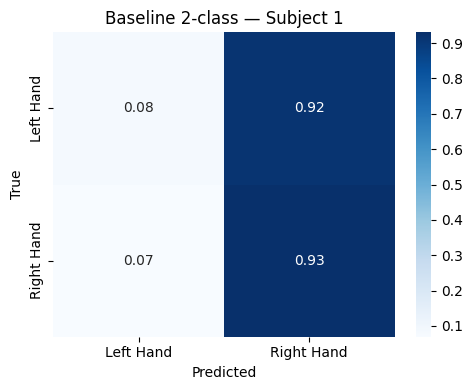

Counts:
  Left  predicted as Left:  6  | as Right: 66
  Right predicted as Left:  5  | as Right: 67


In [6]:
# --- Confusion Matrix: Baseline 2-class ---
y_pred_baseline = np.argmax(model_baseline.predict(X_test_prep), axis=1)

cm = confusion_matrix(y_test, y_pred_baseline, normalize='true')
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=['Left Hand', 'Right Hand'],
            yticklabels=['Left Hand', 'Right Hand'])
plt.ylabel('True')
plt.xlabel('Predicted')
plt.title(f'Baseline 2-class — Subject {SUBJECT_ID}')
plt.tight_layout()
plt.show()

# Counts version
cm_counts = confusion_matrix(y_test, y_pred_baseline)
print('Counts:')
print(f'  Left  predicted as Left:  {cm_counts[0,0]}  | as Right: {cm_counts[0,1]}')
print(f'  Right predicted as Left:  {cm_counts[1,0]}  | as Right: {cm_counts[1,1]}')

### Reflexão

- Quanto a acurácia subiu em relação ao baseline de 4 classes (66.7%)?
- O recall ficou equilibrado entre as duas classes ou uma domina?
- Com 144 trials de treino (vs 288 no 4-class), o overfitting ficou melhor ou pior?

---
## Exercício 2 — Ajuste de Banda: Foco em Mu/Beta (8-30 Hz)

### Pense Primeiro

O filtro atual é 4-40 Hz. Pense no que cada faixa de frequência contém:
- **4-8 Hz (theta)**: atividade atencional, memória de trabalho — relevante para MI?
- **8-13 Hz (mu/alpha)**: ritmo sensorimotor — onde mora o ERD/ERS de motor imagery
- **13-30 Hz (beta)**: rebound motor, sincronização pós-movimento
- **30-40 Hz (gamma baixo)**: processamento cognitivo de alto nível, mas também muito artefato muscular (EMG)

Se incluímos theta e gamma, estamos adicionando **sinal relevante** ou **ruído** para o problema de MI?

### Contexto

A literatura de motor imagery BCI converge em 8-30 Hz como a banda ótima. O ritmo **mu** (8-13 Hz, centrado em ~10 Hz) é o principal marcador — ele dessincroniza (ERD) durante imaginação motora sobre o córtex motor contralateral. O ritmo **beta** (13-30 Hz) complementa com o *beta rebound* — uma sincronização que ocorre após o período de imaginação.

Incluir 4-8 Hz adiciona atividade theta que é mais relacionada a atenção/memória e varia muito entre trials. Incluir 30-40 Hz traz artefatos de EMG (contração muscular) que podem confundir o classificador.

### Exercício

Recarregue os dados com banda 8-30 Hz e retreine o modelo.

C:\Users\pedro\scoop\apps\python\current\Lib\contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


C:\Users\pedro\scoop\apps\python\current\Lib\contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Epoch 1/300


1/4 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.5000 - loss: 0.6994

2/4 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.4922 - loss: 0.6978

...

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step



=== 2class_8-30Hz ===
Train size: 144 | Test size: 144
Accuracy: 0.5069 | Kappa: 0.0139
              precision    recall  f1-score   support

   Left Hand       0.51      0.57      0.54        72
  Right Hand       0.51      0.44      0.47        72

    accuracy                           0.51       144
   macro avg       0.51      0.51      0.51       144
weighted avg       0.51      0.51      0.51       144

1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step

3/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


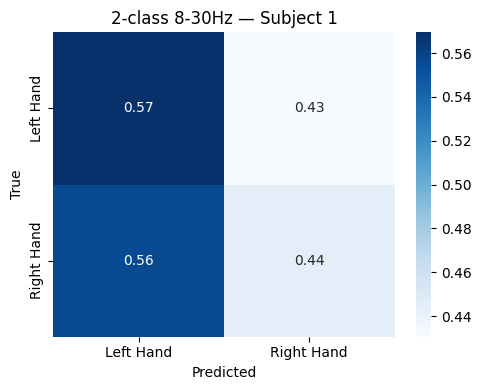

In [7]:
# --- Exercício 2: Recarregar com banda 8-30 Hz ---

X_train_band, y_train_band = load_subject_2class(SUBJECT_ID, 'T', l_freq=8.0, h_freq=30.0)
X_test_band,  y_test_band  = load_subject_2class(SUBJECT_ID, 'E', l_freq=8.0, h_freq=30.0)

X_train_band_prep = prepare(X_train_band)
X_test_band_prep  = prepare(X_test_band)

model_band, hist_band = train_and_evaluate(
    X_train_band_prep, y_train_band, X_test_band_prep, y_test_band,
    n_classes=2, experiment_name='2class_8-30Hz'
)

# --- Confusion Matrix ---
y_pred_band = np.argmax(model_band.predict(X_test_band_prep), axis=1)

cm = confusion_matrix(y_test_band, y_pred_band, normalize='true')
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=['Left Hand', 'Right Hand'],
            yticklabels=['Left Hand', 'Right Hand'])
plt.ylabel('True')
plt.xlabel('Predicted')
plt.title(f'2-class 8-30Hz — Subject {SUBJECT_ID}')
plt.tight_layout()
plt.show()

### Reflexão

- A acurácia melhorou, piorou, ou ficou estável em relação ao baseline 2-class?
- Se melhorou: o ganho veio de qual classe? Olhe recall por classe.
- Se não melhorou: pode ser que o EEGNet já esteja aprendendo a ignorar as bandas irrelevantes internamente (a primeira camada convolucional é um filtro temporal aprendido). O que isso diz sobre a capacidade da rede?

---
## Exercício 3 — Data Augmentation: Gaussian Noise Injection

### Pense Primeiro

Temos ~144 trials de treino para 2 classes. Um modelo com ~4000 parâmetros pode facilmente decorar 144 exemplos.

- Se você adicionar ruído gaussiano a uma época de EEG, o conteúdo neural (ERD/ERS) é destruído?
- Qual seria um nível razoável de ruído? Se o sinal tem std=1 (após z-score), quanto de noise você adicionaria?
- Se gerar 5 cópias ruidosas de cada trial, o dataset vai de 144 para quantos trials?

### Contexto

EEG é inerentemente ruidoso — cada trial tem ruído de fundo diferente (atividade neural espontânea, artefatos sutis, variação de impedância). O sinal de motor imagery (ERD/ERS) é uma modulação **relativamente lenta** na potência de mu/beta, então é robusto a ruído aditivo de alta frequência.

Gaussian noise injection simula essa variabilidade natural: cada cópia augmentada é como um "trial alternativo" onde o sujeito fez a mesma imaginação mas com ruído de fundo diferente. A chave é calibrar a amplitude do ruído — alto demais destrói o sinal, baixo demais não ajuda.

Uma regra de partida: `noise_std` entre 0.05 e 0.2 relativo ao std da época.

### Exercício

Implemente a função de augmentation e treine com dados aumentados.

In [8]:
def augment_gaussian_noise(X, y, n_copies=5, noise_std=0.1):
    """
    Gera n_copies versões ruidosas de cada época.
    noise_std é relativo ao std de cada época individual.
    """
    augmented = [X]          # começa com os originais
    labels    = [y]

    for _ in range(n_copies):
        # std por época: shape (n, 1, 1) para broadcast sobre (n, C, T)
        epoch_std = X.std(axis=(1, 2), keepdims=True)

        # ruído com mesma shape de X, escalado pelo std de cada época
        noise = np.random.randn(*X.shape).astype(np.float32) * (noise_std * epoch_std)

        augmented.append(X + noise)
        labels.append(y)

    return np.concatenate(augmented), np.concatenate(labels)


# --- Teste rápido ---
X_demo = np.random.randn(10, 22, 100).astype(np.float32)
y_demo = np.array([0,1,0,1,0,1,0,1,0,1])
X_a, y_a = augment_gaussian_noise(X_demo, y_demo, n_copies=3, noise_std=0.1)
print(f'Original: {X_demo.shape} -> Augmented: {X_a.shape}')
assert X_a.shape[0] == 10 + 10*3 == 40
print('OK!')

Original: (10, 22, 100) -> Augmented: (40, 22, 100)
OK!


Treino original: 144 -> Augmented: 864 trials


Epoch 1/300


 1/22 ━━━━━━━━━━━━━━━━━━━━ 55s 3s/step - accuracy: 0.5625 - loss: 0.6607

 2/22 ━━━━━━━━━━━━━━━━━━━━ 2s 133ms/step - accuracy: 0.5469 - loss: 0.6697

 3/22 ━━━━━━━━━━━━━━━━━━━━ 2s 132ms/step - accuracy: 0.5278 - loss: 0.6779

...

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step



=== 2class_noise_aug ===
Train size: 864 | Test size: 144
Accuracy: 0.8889 | Kappa: 0.7778
              precision    recall  f1-score   support

   Left Hand       0.86      0.93      0.89        72
  Right Hand       0.92      0.85      0.88        72

    accuracy                           0.89       144
   macro avg       0.89      0.89      0.89       144
weighted avg       0.89      0.89      0.89       144

1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step

3/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


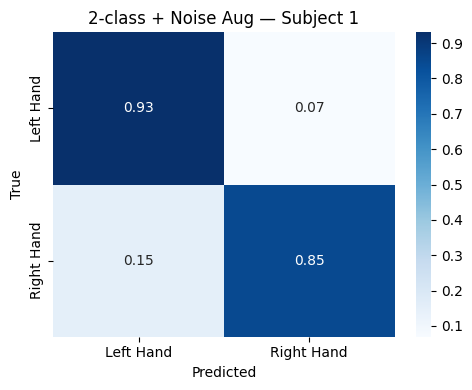

In [9]:
# --- Exercício 3: Treinar com noise augmentation ---
# Usando banda 4-40 Hz (melhor que 8-30 Hz no Ex.2)

# Augmentar dados BRUTOS de treino (antes de normalizar!)
X_train_aug, y_train_aug = augment_gaussian_noise(X_train, y_train, n_copies=5, noise_std=0.1)
print(f'Treino original: {X_train.shape[0]} -> Augmented: {X_train_aug.shape[0]} trials')

# Normalizar e reshape DEPOIS de augmentar
X_train_aug_prep = prepare(X_train_aug)
X_test_prep      = prepare(X_test)       # teste nunca recebe augmentation

model_noise, hist_noise = train_and_evaluate(
    X_train_aug_prep, y_train_aug, X_test_prep, y_test,
    n_classes=2, experiment_name='2class_noise_aug'
)

# --- Confusion Matrix ---
y_pred_noise = np.argmax(model_noise.predict(X_test_prep), axis=1)

cm = confusion_matrix(y_test, y_pred_noise, normalize='true')
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=['Left Hand', 'Right Hand'],
            yticklabels=['Left Hand', 'Right Hand'])
plt.ylabel('True')
plt.xlabel('Predicted')
plt.title(f'2-class + Noise Aug — Subject {SUBJECT_ID}')
plt.tight_layout()
plt.show()

### Reflexão

- O gap entre train accuracy e val accuracy diminuiu? (Isso indica menos overfitting)
- Experimente variar `noise_std` (0.05, 0.1, 0.2) e `n_copies` (3, 5, 10). Qual combinação dá o melhor test accuracy?
- Se aumentar demais o ruído, o que acontece? Por quê?

---
## Report Pós-Augmentation: 4 Classes vs 2 Classes

Comparação de métricas (Accuracy, R², Cohen's Kappa, F1) após Gaussian Noise Augmentation para os cenários de **4 classes** (left hand, right hand, feet, tongue) e **2 classes** (left hand, right hand).

In [10]:
from sklearn.metrics import r2_score, f1_score, precision_score, recall_score
from sklearn.preprocessing import label_binarize

# --- Loader 4-class ---
def load_subject_4class(subject_id: int, split: str = 'T',
                        l_freq: float = 4.0, h_freq: float = 40.0):
    CODE_TO_IDX = {769: 0, 770: 1, 771: 2, 772: 3}
    EVENT_ID = {'left_hand': 769, 'right_hand': 770, 'feet': 771, 'tongue': 772}

    fname = DATA_DIR / f'A0{subject_id}{split}.gdf'
    raw = read_raw_gdf(str(fname), preload=True, verbose=False)
    raw.pick_types(eeg=True)
    raw.pick(raw.ch_names[:N_CHANNELS])
    raw.filter(l_freq=l_freq, h_freq=h_freq, method='iir', verbose=False)

    if split == 'T':
        ann_to_code = {str(k): k for k in CODE_TO_IDX}
        events, _ = mne.events_from_annotations(raw, event_id=ann_to_code, verbose=False)
        events = events[np.isin(events[:, 2], list(CODE_TO_IDX.keys()))]
        epochs = mne.Epochs(raw, events, event_id=EVENT_ID,
                            tmin=0.0, tmax=4.0, baseline=None,
                            preload=True, verbose=False)
        X = epochs.get_data().astype(np.float32)
        y = np.array([CODE_TO_IDX[c] for c in epochs.events[:, 2]], dtype=np.int32)
    else:
        events, _ = mne.events_from_annotations(raw, event_id={'783': 783}, verbose=False)
        epochs = mne.Epochs(raw, events, event_id={'cue': 783},
                            tmin=0.0, tmax=4.0, baseline=None,
                            preload=True, verbose=False)
        X = epochs.get_data().astype(np.float32)
        mat = loadmat(str(LABELS_DIR / f'A0{subject_id}E.mat'))
        y = (mat['classlabel'].flatten() - 1).astype(np.int32)
        y = y[:len(X)]

    return X, y

# --- Carregar dados 4-class ---
X_train_4c, y_train_4c = load_subject_4class(SUBJECT_ID, 'T')
X_test_4c,  y_test_4c  = load_subject_4class(SUBJECT_ID, 'E')
print(f'4-class Train: {X_train_4c.shape}, classes: {np.unique(y_train_4c, return_counts=True)}')
print(f'4-class Test:  {X_test_4c.shape},  classes: {np.unique(y_test_4c,  return_counts=True)}')

C:\Users\pedro\scoop\apps\python\current\Lib\contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


C:\Users\pedro\scoop\apps\python\current\Lib\contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


4-class Train: (288, 22, 1001), classes: (array([0, 1, 2, 3], dtype=int32), array([72, 72, 72, 72]))
4-class Test:  (288, 22, 1001),  classes: (array([0, 1, 2, 3], dtype=int32), array([72, 72, 72, 72]))


In [11]:
# --- Augmentation + Treino 4-class ---
X_train_4c_aug, y_train_4c_aug = augment_gaussian_noise(X_train_4c, y_train_4c, n_copies=5, noise_std=0.1)
print(f'4-class: {X_train_4c.shape[0]} -> {X_train_4c_aug.shape[0]} trials (augmented)')

X_train_4c_aug_prep = prepare(X_train_4c_aug)
X_test_4c_prep      = prepare(X_test_4c)

CLASS_NAMES_4 = ['Left Hand', 'Right Hand', 'Feet', 'Tongue']

model_4c_aug, hist_4c_aug = train_and_evaluate(
    X_train_4c_aug_prep, y_train_4c_aug, X_test_4c_prep, y_test_4c,
    n_classes=4, experiment_name='4class_noise_aug',
    epochs=100, batch_size=64, patience=15
)

4-class: 288 -> 1728 trials (augmented)


Epoch 1/100


 1/22 ━━━━━━━━━━━━━━━━━━━━ 1:00 3s/step - accuracy: 0.2344 - loss: 1.4710

 2/22 ━━━━━━━━━━━━━━━━━━━━ 6s 320ms/step - accuracy: 0.2695 - loss: 1.4469

 3/22 ━━━━━━━━━━━━━━━━━━━━ 5s 314ms/step - accuracy: 0.2769 - loss: 1.4353

...

5/9 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step

7/9 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step



=== 4class_noise_aug ===
Train size: 1728 | Test size: 288
Accuracy: 0.8021 | Kappa: 0.7361
              precision    recall  f1-score   support

   Left Hand       0.92      0.79      0.85        72
  Right Hand       0.87      0.94      0.91        72
        Feet       0.68      0.79      0.73        72
      Tongue       0.77      0.68      0.72        72

    accuracy                           0.80       288
   macro avg       0.81      0.80      0.80       288
weighted avg       0.81      0.80      0.80       288



In [12]:
# ===================================================================
# Report Pós-Augmentation: Métricas Completas — 4 Classes vs 2 Classes
# ===================================================================

def compute_report(model, X_test, y_test, n_classes, class_names):
    """Computa métricas completas: accuracy, R², kappa, F1, precision, recall."""
    y_proba = model.predict(X_test, verbose=0)
    y_pred  = np.argmax(y_proba, axis=1)

    acc   = (y_pred == y_test).mean()
    kappa = cohen_kappa_score(y_test, y_pred)

    y_test_oh = label_binarize(y_test, classes=list(range(n_classes)))
    if n_classes == 2:
        y_test_oh = np.hstack([1 - y_test_oh, y_test_oh])
    r2 = r2_score(y_test_oh, y_proba, multioutput='uniform_average')

    f1   = f1_score(y_test, y_pred, average='macro')
    prec = precision_score(y_test, y_pred, average='macro')
    rec  = recall_score(y_test, y_pred, average='macro')

    confidence_correct   = y_proba[y_pred == y_test].max(axis=1).mean() if (y_pred == y_test).any() else 0
    confidence_incorrect = y_proba[y_pred != y_test].max(axis=1).mean() if (y_pred != y_test).any() else 0

    return {
        'accuracy': acc, 'r2': r2, 'kappa': kappa,
        'f1_macro': f1, 'precision_macro': prec, 'recall_macro': rec,
        'mean_confidence_correct': confidence_correct,
        'mean_confidence_incorrect': confidence_incorrect,
        'y_pred': y_pred, 'y_proba': y_proba,
    }

# --- 4-class report ---
CLASS_NAMES_2 = ['Left Hand', 'Right Hand']
report_4c = compute_report(model_4c_aug, X_test_4c_prep, y_test_4c, 4, CLASS_NAMES_4)
report_2c = compute_report(model_noise,  X_test_prep,    y_test,    2, CLASS_NAMES_2)

# --- Tabela Comparativa ---
print('=' * 70)
print(f'{"METRIC":<30} {"4 CLASSES":>15} {"2 CLASSES":>15}')
print('=' * 70)
for metric in ['accuracy', 'r2', 'kappa', 'f1_macro', 'precision_macro', 'recall_macro',
               'mean_confidence_correct', 'mean_confidence_incorrect']:
    label = metric.replace('_', ' ').title()
    v4 = report_4c[metric]
    v2 = report_2c[metric]
    print(f'{label:<30} {v4:>15.4f} {v2:>15.4f}')
print('=' * 70)
print(f'{"Train size (augmented)":<30} {len(X_train_4c_aug):>15d} {len(X_train_aug):>15d}')
print(f'{"Test size":<30} {len(X_test_4c):>15d} {len(X_test):>15d}')
print(f'{"Chance level":<30} {"25.0%":>15} {"50.0%":>15}')

METRIC                               4 CLASSES       2 CLASSES
Accuracy                                0.8021          0.8889
R2                                      0.6202          0.6741
Kappa                                   0.7361          0.7778
F1 Macro                                0.8022          0.8887
Precision Macro                         0.8088          0.8916
Recall Macro                            0.8021          0.8889
Mean Confidence Correct                 0.8270          0.9402
Mean Confidence Incorrect               0.6698          0.7510
Train size (augmented)                    1728             864
Test size                                  288             144
Chance level                             25.0%           50.0%


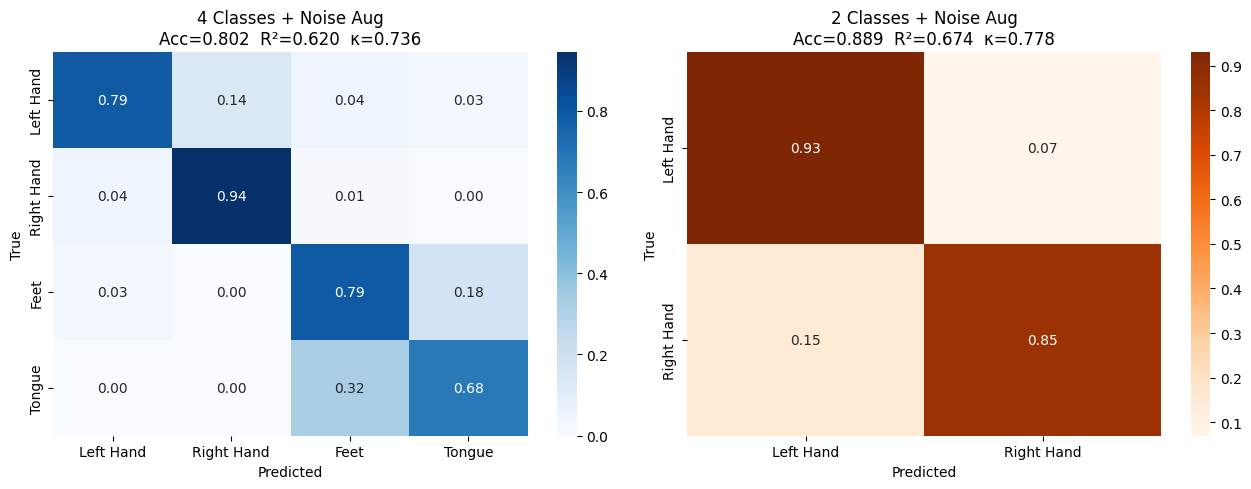

In [13]:
# --- Visualização: Confusion Matrices lado a lado ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 4-class
cm4 = confusion_matrix(y_test_4c, report_4c['y_pred'], normalize='true')
sns.heatmap(cm4, annot=True, fmt='.2f', cmap='Blues', ax=axes[0],
            xticklabels=CLASS_NAMES_4, yticklabels=CLASS_NAMES_4)
axes[0].set_ylabel('True')
axes[0].set_xlabel('Predicted')
axes[0].set_title(f'4 Classes + Noise Aug\nAcc={report_4c["accuracy"]:.3f}  R²={report_4c["r2"]:.3f}  κ={report_4c["kappa"]:.3f}')

# 2-class
cm2 = confusion_matrix(y_test, report_2c['y_pred'], normalize='true')
sns.heatmap(cm2, annot=True, fmt='.2f', cmap='Oranges', ax=axes[1],
            xticklabels=CLASS_NAMES_2, yticklabels=CLASS_NAMES_2)
axes[1].set_ylabel('True')
axes[1].set_xlabel('Predicted')
axes[1].set_title(f'2 Classes + Noise Aug\nAcc={report_2c["accuracy"]:.3f}  R²={report_2c["r2"]:.3f}  κ={report_2c["kappa"]:.3f}')

plt.tight_layout()
plt.show()

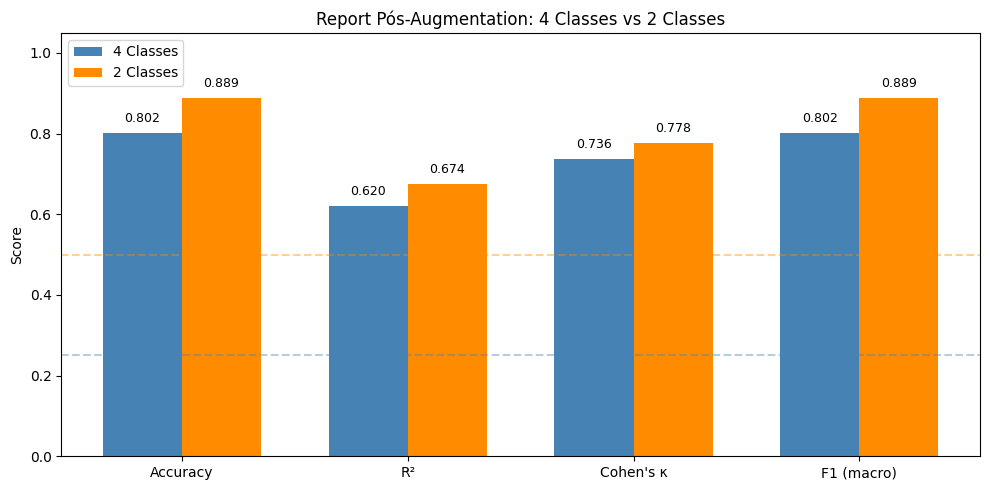

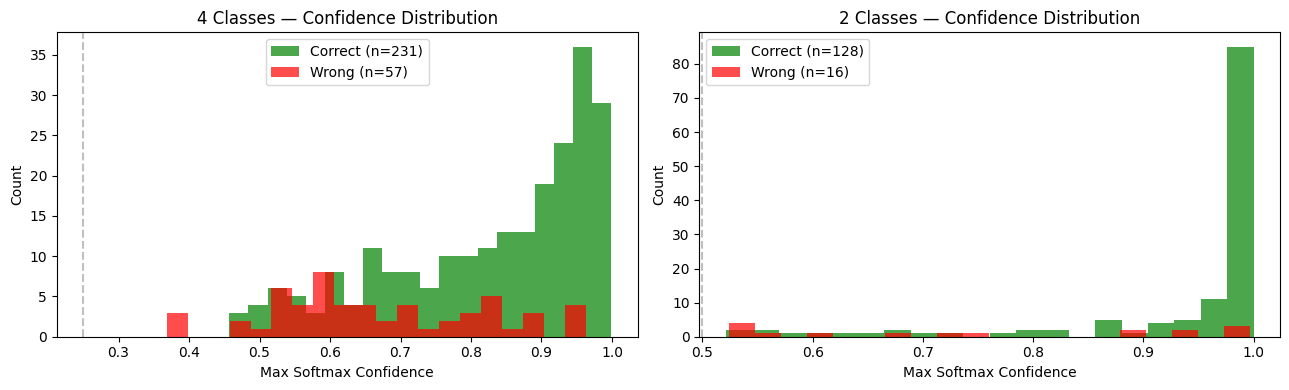

In [14]:
# --- Barras comparativas: Accuracy, R², Kappa, F1 ---
metrics_to_plot = ['accuracy', 'r2', 'kappa', 'f1_macro']
labels_plot     = ['Accuracy', 'R²', "Cohen's κ", 'F1 (macro)']

vals_4c = [report_4c[m] for m in metrics_to_plot]
vals_2c = [report_2c[m] for m in metrics_to_plot]

x = np.arange(len(metrics_to_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars_4 = ax.bar(x - width/2, vals_4c, width, label='4 Classes', color='steelblue')
bars_2 = ax.bar(x + width/2, vals_2c, width, label='2 Classes', color='darkorange')

ax.set_ylabel('Score')
ax.set_title('Report Pós-Augmentation: 4 Classes vs 2 Classes')
ax.set_xticks(x)
ax.set_xticklabels(labels_plot)
ax.set_ylim(0, 1.05)
ax.legend()
ax.axhline(y=0.25, color='steelblue', linestyle='--', alpha=0.4, label='Chance 4c (25%)')
ax.axhline(y=0.50, color='darkorange', linestyle='--', alpha=0.4, label='Chance 2c (50%)')

for bar in bars_4:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars_2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# --- Distribuição de confiança do softmax ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, report, title, n_cls in [(axes[0], report_4c, '4 Classes', 4),
                                  (axes[1], report_2c, '2 Classes', 2)]:
    y_t = y_test_4c if n_cls == 4 else y_test
    correct = report['y_proba'].max(axis=1)[report['y_pred'] == y_t]
    wrong   = report['y_proba'].max(axis=1)[report['y_pred'] != y_t]

    ax.hist(correct, bins=20, alpha=0.7, label=f'Correct (n={len(correct)})', color='green')
    ax.hist(wrong,   bins=20, alpha=0.7, label=f'Wrong (n={len(wrong)})',   color='red')
    ax.set_xlabel('Max Softmax Confidence')
    ax.set_ylabel('Count')
    ax.set_title(f'{title} — Confidence Distribution')
    ax.legend()
    ax.axvline(x=1/n_cls, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

---
## Exercício 4 — Data Augmentation: Sliding Window Temporal

### Pense Primeiro

Cada trial é uma janela de 4 segundos (0 a 4s pós-cue). Mas pense:
- O padrão de ERD começa exatamente em t=0 ou leva algum tempo para se desenvolver?
- A janela [0.5s, 3.5s] conteria a mesma informação de MI que [0s, 3s]?
- Se extraímos 5 janelas sobrepostas de 3s de cada trial de 4s, quantos exemplos de treino teremos?

Agora pense no contexto do jogo online:
- Se o modelo precisar de 4 segundos de dados para classificar, qual é a latência mínima de resposta?
- Se treinarmos com janelas de 2 segundos, essa latência cai para quanto?

### Contexto

O ERD de motor imagery tipicamente começa ~500ms após o cue e atinge o pico entre 1-2 segundos. Isso significa que uma janela de 2-3 segundos bem posicionada captura a maior parte da informação discriminativa.

Sliding window augmentation explora isso: de cada trial de 4s, extraímos múltiplas sub-janelas sobrepostas. Isso serve dois propósitos:
1. **Multiplica dados** — cada trial gera N sub-janelas
2. **Treina para janelas mais curtas** — essencial para o sistema online (menor latência)

O tradeoff: janelas mais curtas = menos informação temporal = classificação potencialmente pior. Mas com mais exemplos de treino, o modelo generaliza melhor. Na prática, 2-3 segundos é o sweet spot.

**Nota sobre o teste**: no test set, você pode usar uma única janela central, ou classificar múltiplas janelas e fazer **majority voting**.

### Exercício

Implemente sliding window augmentation e treine com janelas mais curtas.

In [15]:
def augment_sliding_window(X, y, window_sec=2.0, step_sec=0.5, sfreq=250):
    """
    Extrai sub-janelas sobrepostas de cada época.
    
    Args:
        X: (n_epochs, n_channels, n_times)
        y: (n_epochs,)
        window_sec: duração de cada janela em segundos
        step_sec: passo entre janelas em segundos
    
    Returns:
        X_windows: (n_total_windows, n_channels, window_samples)
        y_windows: (n_total_windows,)
    """
    # TODO
    pass


# --- Teste rápido ---
# X_demo = np.random.randn(10, 22, 1001).astype(np.float32)  # 10 trials, 4s
# y_demo = np.zeros(10, dtype=np.int32)
# X_w, y_w = augment_sliding_window(X_demo, y_demo, window_sec=2.0, step_sec=0.5)
# print(f'Original: {X_demo.shape} -> Windows: {X_w.shape}')
# # 4s epoch, 2s window, 0.5s step => 5 windows per trial => 50 total
# # window_samples = 2.0 * 250 = 500

In [16]:
# TODO: Aplicar sliding window nos dados de treino
# TODO: Para o teste, decidir estratégia:
#   Opção A) janela central única (ex: crop do meio da época)
#   Opção B) múltiplas janelas + majority voting
#
# Dica: Opção B geralmente dá melhor resultado, mas requer um pouco
# mais de lógica. Tente A primeiro, depois B se quiser.

# model_sw, hist_sw = train_and_evaluate(
#     ..., experiment_name='2class_8-30Hz_slidingwindow'
# )

### Reflexão

- Compare o número de trials de treino com vs sem sliding window. Quantas vezes multiplicou?
- A acurácia no test set melhorou em relação ao noise-only?
- Se você usou majority voting no teste: qual foi a acurácia por janela individual vs a acurácia após voting?
- Para o jogo online: qual seria a latência de resposta com janelas de 2s vs 4s?

---
## Exercício 5 — Pipeline Completo: Todas as Melhorias Combinadas

### Pense Primeiro

Agora que você testou cada técnica isoladamente, é hora de combinar:
- Faz sentido aplicar noise augmentation + sliding window ao mesmo tempo?
- Em que ordem você aplicaria? (sliding window primeiro ou noise primeiro?)
- Se combinar tudo, o dataset pode ficar muito grande. Qual é o risco de ter dados demais? (Dica: pense no tempo de treino e no equilíbrio entre dados originais vs augmentados)

### Exercício

Monte o pipeline final combinando: 2 classes + banda 8-30 Hz + sliding window + gaussian noise.

In [17]:
# TODO: Pipeline completo
# 1. Carregar dados 2-class, banda 8-30 Hz
# 2. Aplicar sliding window no treino
# 3. Aplicar noise augmentation nos windows
# 4. Normalizar e reshape
# 5. Treinar e avaliar
#
# Sugestão de ordem: sliding window ANTES de noise
# (noise em cima de windows curtos é mais realista)
#
# Cuidado com o tamanho: se 144 trials * 5 windows * 5 noise copies = 3600
# Pode ser necessário reduzir n_copies ou aumentar batch_size

# model_full, hist_full = train_and_evaluate(
#     ..., experiment_name='full_pipeline'
# )

---
## Exercício 6 — Comparação Final e Export do Modelo

### Exercício

Plote uma comparação de todos os experimentos e salve o melhor modelo.

In [18]:
# TODO: Plotar comparação de resultados
# O dict 'results' contém todos os experimentos.
# Crie um gráfico de barras comparando accuracy e kappa.

# print('\n=== Resumo de Resultados ===')
# for name, r in results.items():
#     print(f"{name:30s} | acc={r['accuracy']:.4f} | κ={r['kappa']:.4f} | n_train={r['n_train']}")

In [19]:
# TODO: Plotar barras de comparação
# fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# names = list(results.keys())
# accs  = [results[n]['accuracy'] for n in names]
# kappas = [results[n]['kappa'] for n in names]
#
# axes[0].bar(names, accs); axes[0].set_ylabel('Accuracy'); axes[0].set_ylim(0.5, 1.0)
# axes[1].bar(names, kappas); axes[1].set_ylabel('Cohen kappa'); axes[1].set_ylim(0.0, 1.0)
# for ax in axes: ax.tick_params(axis='x', rotation=30)
# plt.tight_layout(); plt.show()

In [20]:
# TODO: Salvar o melhor modelo para uso no jogo online
# best_name = max(results, key=lambda k: results[k]['accuracy'])
# print(f'Melhor experimento: {best_name} (acc={results[best_name]["accuracy"]:.4f})')
#
# Salvar com um nome descritivo:
# model_full.save(MODELS_DIR / 'eegnet_2class_best.keras')
#
# Para uso online, salvar também os metadados de preprocessamento:
# import json
# meta = {
#     'n_channels': N_CHANNELS,
#     'sfreq': SFREQ,
#     'n_classes': 2,
#     'class_names': ['left_hand', 'right_hand'],
#     'l_freq': 8.0,
#     'h_freq': 30.0,
#     'window_sec': 2.0,  # se usou sliding window
#     'window_samples': 500,
#     'normalization': 'zscore_per_epoch',
# }
# with open(MODELS_DIR / 'eegnet_2class_meta.json', 'w') as f:
#     json.dump(meta, f, indent=2)
# print('Modelo e metadados salvos.')

### Reflexão Final

- Qual técnica deu o maior salto de acurácia individual?
- O resultado final é suficiente para controlar o jogo de forma jogável? (Pense: se 1 em cada 5 comandos sai errado, a experiência é frustrante?)
- O que mais poderia ser feito para melhorar? Considere:
  - Treinar subject-specific com fine-tuning de um modelo multi-subject
  - Adicionar um **threshold de confiança** — só enviar comando se softmax > 0.7, caso contrário manter idle
  - Usar **ensemble** de modelos treinados com diferentes augmentations

---

**Próximo passo**: Com o modelo salvo e os metadados de preprocessamento, estamos prontos para montar o módulo de inferência online que conecta no jogo via TCP.